# BetterRnnlm

这个 notebook 用来基于 `my-torch-lib` 手动训练第 6.5.4 节的改进版语言模型 `BetterRnnlm`。

相较于 `Rnnlm`，这一版模型加入了三点改进：

- 两层 `TimeLSTM`
- 深度方向上的 `TimeDropout`
- `TimeEmbedding` 和输出 `TimeLinear` 的权重共享

注意：`BetterRnnlm.forward(xs)` 只返回 logits，loss 仍然在模型外部单独计算。


## 环境准备：说明

这一步的目标是把 notebook 运行环境接到 `deep_learning_implementation`、`my-torch-lib` 和 `my-eval-lib`。

后面会用到 PTB 数据、`BetterRnnlm`、时间版损失层、SGD、梯度裁剪、连续语料 batch helper 和困惑度函数。


In [1]:
from pathlib import Path
import time
import sys
import random
import torch
import numpy as np

projects_dir = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(".."))
sys.path.insert(0, str(projects_dir / "my-torch-lib"))
sys.path.insert(0, str(projects_dir / "my-eval-lib"))

from dataset import ptb
from torchlib.models.rnnlm import BetterRnnlm
from torchlib.layers.softmax_loss import TimeSoftmaxWithLoss
from torchlib.optim.sgd import SGD
from torchlib.utils.grad import clip_grads
from torchlib.utils.rnnlm import create_rnnlm_offsets, create_rnnlm_batch
from eval.metrics import perplexity


## 超参数设置：说明

默认使用 smoke 配置，优先保证 notebook 能快速跑通。完整实验时再切到 full 配置。

`BetterRnnlm` 做权重共享时要求 `wordvec_size == hidden_size`，两个配置都保持这两个维度相等。


In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
run_profile = "full"

if run_profile == "smoke":
    batch_size = 20
    wordvec_size = 100
    hidden_size = 100
    time_size = 35
    lr = 20.0
    max_epoch = 1
    max_grad = 0.25
    dropout = 0.5
    corpus_size = 5000
else:
    batch_size = 20
    wordvec_size = 650
    hidden_size = 650
    time_size = 35
    lr = 20.0
    max_epoch = 40
    max_grad = 0.25
    dropout = 0.5
    corpus_size = None

eval_interval = 100
checkpoint_dir = Path("checkpoints")
checkpoint_path = checkpoint_dir / "better_rnnlm_best.pt"

print("device:", device)
print("run_profile:", run_profile)


device: cuda
run_profile: full


## 读取 PTB 数据：说明

这里读取训练集、验证集和测试集。训练输入和监督标签仍然按语言模型的标准方式相差一个时间步：

- `xs = corpus_train[:-1]`
- `ts = corpus_train[1:]`

`vocab_size` 使用完整词表大小 `len(word_to_id)`，不要用截断后语料的 unique 数量，否则 embedding 可能覆盖不到语料中的原始词 ID。


In [3]:
corpus_train, word_to_id, id_to_word = ptb.load_data("train")
corpus_val, _, _ = ptb.load_data("val")
corpus_test, _, _ = ptb.load_data("test")

corpus_train = corpus_train[:corpus_size]
xs = corpus_train[:-1]
ts = corpus_train[1:]

data_size = len(xs)
vocab_size = len(word_to_id)

print("train corpus size:", len(corpus_train))
print("data_size:", data_size)
print("vocab_size:", vocab_size)


train corpus size: 929589
data_size: 929588
vocab_size: 10000


## 张量化：说明

模型输入仍然是词 ID，不需要手动构造 one-hot。`TimeEmbedding` 接收整型 token id。


In [4]:
xs = torch.tensor(xs, dtype=torch.long)
ts = torch.tensor(ts, dtype=torch.long)

corpus_val = torch.tensor(corpus_val, dtype=torch.long)
corpus_test = torch.tensor(corpus_test, dtype=torch.long)

xs.shape, ts.shape, corpus_val.shape, corpus_test.shape


(torch.Size([929588]),
 torch.Size([929588]),
 torch.Size([73760]),
 torch.Size([82430]))

## Offsets 与时间状态：说明

连续语料 batch 的构造方式和 `rnnlm.ipynb` 相同：把一整条语料切成 `batch_size` 条并行子序列，并维护一个跨 iteration 递增的 `time_idx`。


In [5]:
time_idx = 0
max_iters = data_size // (batch_size * time_size)
offsets = create_rnnlm_offsets(data_size, batch_size)

print("max_iters:", max_iters)
print("offsets[:5]:", offsets[:5])


max_iters: 1327
offsets[:5]: [0, 46479, 92958, 139437, 185916]


## 初始化模型、损失与优化器

这一格留给你实现。推荐准备：

- `BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout, stateful=True)`
- `TimeSoftmaxWithLoss()`
- `SGD(model.parameters(), lr)`

自查：为什么 loss 仍然不写进 `BetterRnnlm.forward()`？


In [6]:
model = BetterRnnlm(vocab_size, wordvec_size, hidden_size, dropout, stateful=True).to(device)
criterion = TimeSoftmaxWithLoss().to(device)
optimizer = SGD(model.parameters(), lr)

## 单步 Batch 演示：说明

在进入完整训练循环前，先单独调一次 `create_rnnlm_batch(...)`，确认 batch 形状和 `time_idx` 推进方式。


In [7]:
batch_x, batch_t, next_time_idx = create_rnnlm_batch(
    xs=xs,
    ts=ts,
    batch_size=batch_size,
    time_size=time_size,
    time_idx=time_idx,
    offsets=offsets,
)

batch_x.shape, batch_t.shape, next_time_idx


(torch.Size([20, 35]), torch.Size([20, 35]), 35)

## 单步训练函数

这一格留给你实现一次参数更新。推荐顺序：

- 将 batch 移动到 `device`
- 前向得到 logits
- 在模型外部计算 loss
- 清梯度、反向传播、梯度裁剪、优化器更新
- 调用 `model.truncate_state()`

自查：为什么 stateful LSTM 在每个分段训练后需要截断反向传播历史？


In [8]:
def train_step(batch_x, batch_t):
    batch_x = batch_x.to(device)
    batch_t = batch_t.to(device)

    logits = model(batch_x)
    loss = criterion(logits, batch_t)

    optimizer.zero_grad()
    loss.backward()
    clip_grads(model.parameters(), max_grad)
    optimizer.step()

    model.truncate_state()

    return loss

## 训练进度打印：说明

这部分只是日志辅助，训练逻辑仍留在后面的训练循环中。


In [9]:
def print_train_progress(epoch, i, max_iters, loss, loss_list, start_time, interval=100):
    count = epoch * max_iters + i + 1
    if count % interval != 0:
        return

    elapsed_time = time.time() - start_time
    recent_loss = np.mean(loss_list[-interval:])
    ppl = perplexity(recent_loss)

    print(
        f"| epoch {epoch + 1:>2d} "
        f"| iter {i + 1:>5d} / {max_iters:<5d} "
        f"| step {count:>6d} "
        f"| time {elapsed_time:>6.0f}[s] "
        f"| loss {loss.item():>7.4f} "
        f"| train perplexity {ppl:>8.2f}"
    )


## 验证集困惑度

这一格留给你实现 `evaluate_ppl(model, corpus, batch_size, time_size, device)`。

建议要点：

- 使用 `model.eval()` 和 `torch.no_grad()`
- 评估开始前 `model.reset_state()`
- 用和训练相同的连续语料 batch 方式构造 `xs/ts`
- 累积平均 loss 后调用 `perplexity(avg_loss)`
- 评估结束后恢复原来的 train/eval 状态


In [10]:
def evaluate_ppl(model, corpus, batch_size, time_size, device):
    was_training = model.training
    eval_criterion = TimeSoftmaxWithLoss().to(device)

    model.eval()
    model.reset_state()

    xs_eval = corpus[:-1]
    ts_eval = corpus[1:]
    data_size_eval = len(xs_eval)
    max_iters_eval = data_size_eval // (batch_size * time_size)
    offsets_eval = create_rnnlm_offsets(data_size_eval, batch_size)
    time_idx_eval = 0
    total_loss = 0.0

    with torch.no_grad():
        for _ in range(max_iters_eval):
            batch_x, batch_t, time_idx_eval = create_rnnlm_batch(
                xs=xs_eval,
                ts=ts_eval,
                batch_size=batch_size,
                time_size=time_size,
                time_idx=time_idx_eval,
                offsets=offsets_eval,
            )
            batch_x = batch_x.to(device)
            batch_t = batch_t.to(device)

            logits = model(batch_x)
            loss = eval_criterion(logits, batch_t)
            total_loss += loss.item()

    model.reset_state()
    if was_training:
        model.train()

    avg_loss = total_loss / max_iters_eval
    return perplexity(avg_loss)


## 训练循环

这一格留给你实现完整训练循环。

建议每个 epoch 做这些事：

- 重置 `time_idx` 和模型状态
- 循环 `max_iters` 次训练
- 记录训练 loss 和 train perplexity
- epoch 结束后计算 validation perplexity
- 如果验证集更好，保存 best checkpoint
- 如果验证集没有改善，将学习率除以 4


In [11]:
checkpoint_dir.mkdir(exist_ok=True)

start_time = time.time()
loss_list = []
train_ppl_list = []
val_ppl_list = []
best_val_ppl = float("inf")
current_lr = lr

for epoch in range(max_epoch):
    model.train()
    model.reset_state()
    time_idx = 0
    epoch_loss_list = []

    for i in range(max_iters):
        batch_x, batch_t, time_idx = \
            create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)
        loss = train_step(batch_x, batch_t)
        loss_list.append(loss.item())
        epoch_loss_list.append(loss.item())

        print_train_progress(
            epoch=epoch,
            i=i,
            max_iters=max_iters,
            loss=loss,
            loss_list=loss_list,
            start_time=start_time,
            interval=eval_interval,
        )

    train_ppl = float(perplexity(np.mean(epoch_loss_list)))
    val_ppl = float(evaluate_ppl(model, corpus_val, batch_size, time_size, device))
    train_ppl_list.append(train_ppl)
    val_ppl_list.append(val_ppl)

    print(
        f"| epoch {epoch + 1:>2d} "
        f"| train perplexity {train_ppl:>8.2f} "
        f"| valid perplexity {val_ppl:>8.2f}"
    )

    if val_ppl < best_val_ppl:
        best_val_ppl = val_ppl
        torch.save(
            {
                "model_state": model.state_dict(),
                "best_val_ppl": best_val_ppl,
                "epoch": epoch + 1,
                "lr": current_lr,
            },
            checkpoint_path,
        )
    else:
        current_lr /= 4.0
        for group in optimizer.param_groups:
            group["lr"] = current_lr

    model.reset_state()

| epoch  1 | iter   100 / 1327  | step    100 | time     18[s] | loss  6.6995 | train perplexity  1552.67


| epoch  1 | iter   200 / 1327  | step    200 | time     36[s] | loss  6.3144 | train perplexity   700.36


| epoch  1 | iter   300 / 1327  | step    300 | time     54[s] | loss  6.0877 | train perplexity   532.92


| epoch  1 | iter   400 / 1327  | step    400 | time     72[s] | loss  5.8487 | train perplexity   429.33


| epoch  1 | iter   500 / 1327  | step    500 | time     90[s] | loss  5.9732 | train perplexity   377.11


...

| epoch 40 | iter   947 / 1327  | step  52700 | time   9391[s] | loss  3.8524 | train perplexity    45.07


| epoch 40 | iter  1047 / 1327  | step  52800 | time   9408[s] | loss  3.4687 | train perplexity    44.50


| epoch 40 | iter  1147 / 1327  | step  52900 | time   9425[s] | loss  3.4102 | train perplexity    38.19


| epoch 40 | iter  1247 / 1327  | step  53000 | time   9442[s] | loss  3.5203 | train perplexity    36.57


| epoch 40 | train perplexity    42.88 | valid perplexity    80.00


## 测试集评估

这一格留给你实现最终 test perplexity。

建议流程：加载 best checkpoint，调用 `evaluate_ppl`，打印 `best_val_ppl` 和 `test_ppl`。


In [12]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
best_val_ppl = checkpoint["best_val_ppl"]

test_ppl = evaluate_ppl(model, corpus_test, batch_size, time_size, device)
print(f"best validation perplexity: {best_val_ppl:.2f}")
print(f"test perplexity: {test_ppl:.2f}")


best validation perplexity: 80.00
test perplexity: 76.73


## 困惑度计算与记录：说明

`perplexity` 是纯指标函数。训练或评估流程应先得到平均交叉熵损失，再把平均 loss 传给 `perplexity(avg_loss)`。


In [13]:
print("train_ppl_list:", train_ppl_list)
print("val_ppl_list:", val_ppl_list)


train_ppl_list: [358.4200693173277, 175.6065153941835, 137.24349598827624, 117.123365856135, 104.58305717770578, 96.14412978960866, 89.73260648122843, 85.0016972755914, 80.93764213224989, 77.69861769855785, 74.8853896662793, 72.57380564859493, 70.45936043535916, 68.82329447835481, 67.15241861062168, 65.8092523545833, 64.58945505722342, 63.36564038591089, 55.81276483690677, 52.75883825438228, 51.18085162746623, 49.97845264080682, 49.01561779027743, 48.03351097061586, 47.223592072609044, 45.53104224264004, 44.951116322620024, 44.605805697754214, 44.24388765216439, 43.987949827248414, 43.56568454365828, 43.348010248345794, 43.25350327135241, 43.22923279163347, 43.04102611991598, 42.97779107949367, 42.865739278960405, 42.9567069996994, 42.88002859581671, 42.87886695801574]
val_ppl_list: [202.9194568045498, 147.5725910357209, 125.74322783693904, 112.7763522572578, 105.56989181878492, 100.44830014077236, 97.27640302772225, 94.66865432382414, 92.44067829426302, 90.7849591065196, 90.0767084035

## 绘图：说明

训练跑完后，把训练集和验证集困惑度曲线画出来。重点是确认曲线有没有明显异常，以及 best validation epoch 出现在什么位置。


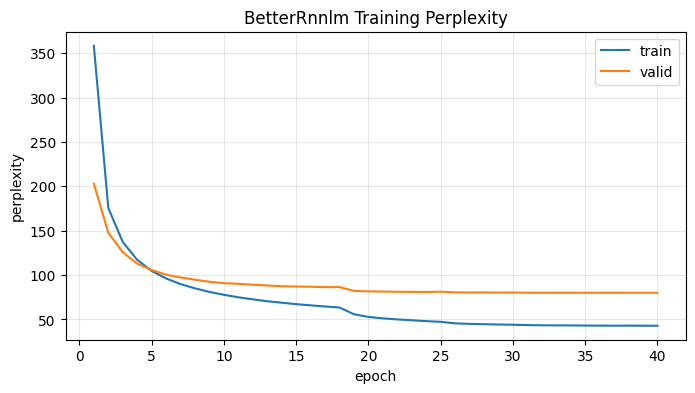

In [14]:
import matplotlib.pyplot as plt

epochs = np.arange(1, len(val_ppl_list) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_ppl_list, label="train")
plt.plot(epochs, val_ppl_list, label="valid")
plt.title("BetterRnnlm Training Perplexity")
plt.xlabel("epoch")
plt.ylabel("perplexity")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 结果反思：说明

这一节的重点是确认你是否理解 BetterRnnlm 相比 Rnnlm 的变化，以及最终实验中验证集和学习率衰减的作用。

建议记录：

- 两层 LSTM 对模型表达能力的影响
- Dropout 为什么放在深度方向
- 权重共享为什么要求 `wordvec_size == hidden_size`
- validation perplexity 变差时为什么降低学习率
- smoke 配置和 full 配置的结果差异
